# Analise inicial do dataset Fashionpedia (val2020)

Este notebook faz uma exploracao inicial completa do arquivo `instances_attributes_val2020.json`, cobrindo:

- Estrutura e significado de cada bloco do JSON
- Quantidades (itens, atributos, imagens, anotacoes, licencas)
- Listas de categorias e atributos
- Funcionamento das anotacoes (categoria por mascara + atributos)
- Balanceamento/desbalanceamento das distribuicoes

In [57]:
from pathlib import Path
import json
from collections import Counter, defaultdict
import statistics
import math

DATA_PATH = Path('original_dataset/instances_attributes_val2020.json')

with DATA_PATH.open('r', encoding='utf-8') as f:
    data = json.load(f)

print(f'Arquivo carregado: {DATA_PATH}')
print('Chaves principais:', list(data.keys()))

Arquivo carregado: original_dataset\instances_attributes_val2020.json
Chaves principais: ['info', 'categories', 'attributes', 'licenses', 'annotations', 'images']


In [58]:
info = data.get('info', {})
categories = data.get('categories', [])
attributes = data.get('attributes', [])
licenses = data.get('licenses', [])
annotations = data.get('annotations', [])
images = data.get('images', [])

summary = {
    'ano': info.get('year'),
    'versao': info.get('version'),
    'descricao': info.get('description'),
    'num_categories': len(categories),
    'num_attributes': len(attributes),
    'num_licenses': len(licenses),
    'num_annotations': len(annotations),
    'num_images': len(images),
}

summary

{'ano': 2020,
 'versao': '1.0',
 'descricao': 'Fashionpedia dataset, annotated with segmentation masks and their associated per-mask fine-grained attributes',
 'num_categories': 46,
 'num_attributes': 294,
 'num_licenses': 12,
 'num_annotations': 8781,
 'num_images': 1158}

In [59]:
def to_records(items):
    out = []
    for x in items:
        out.append({
            'id': x.get('id'),
            'name': x.get('name'),
            'supercategory': x.get('supercategory'),
            'level': x.get('level'),
            'taxonomy_id': x.get('taxonomy_id'),
        })
    return out

category_records = to_records(categories)
attribute_records = to_records(attributes)

print('Exemplo de categoria:')
print(category_records[0] if category_records else 'sem categorias')
print('\nExemplo de atributo:')
print(attribute_records[0] if attribute_records else 'sem atributos')

Exemplo de categoria:
{'id': 0, 'name': 'shirt, blouse', 'supercategory': 'upperbody', 'level': 2, 'taxonomy_id': 'combo000000'}

Exemplo de atributo:
{'id': 0, 'name': 'classic (t-shirt)', 'supercategory': 'nickname', 'level': 1, 'taxonomy_id': 'att000002_00'}


In [60]:
# Exporta listas completas para auditoria externa
out_dir = Path('analysis_outputs')
out_dir.mkdir(exist_ok=True)

categories_path = out_dir / 'categories_full_list.json'
attributes_path = out_dir / 'attributes_full_list.json'
licenses_path = out_dir / 'licenses_full_list.json'

categories_path.write_text(json.dumps(category_records, ensure_ascii=False, indent=2), encoding='utf-8')
attributes_path.write_text(json.dumps(attribute_records, ensure_ascii=False, indent=2), encoding='utf-8')
licenses_path.write_text(json.dumps(licenses, ensure_ascii=False, indent=2), encoding='utf-8')

print('Arquivos exportados:')
print('-', categories_path)
print('-', attributes_path)
print('-', licenses_path)

Arquivos exportados:
- analysis_outputs\categories_full_list.json
- analysis_outputs\attributes_full_list.json
- analysis_outputs\licenses_full_list.json


In [61]:
# Estrutura das anotacoes (como o dataset funciona na pratica)
ann0 = annotations[0] if annotations else {}
print('Campos da anotacao:', sorted(ann0.keys()))

category_name_by_id = {c.get('id'): c.get('name') for c in categories}
attribute_name_by_id = {a.get('id'): a.get('name') for a in attributes}

category_counter = Counter()
attribute_counter = Counter()
attr_per_annotation = []
ann_per_image = Counter()
area_values = []

for ann in annotations:
    cid = ann.get('category_id')
    category_counter[cid] += 1

    attrs = ann.get('attribute_ids') or []
    attr_per_annotation.append(len(attrs))
    for aid in attrs:
        attribute_counter[aid] += 1

    img_id = ann.get('image_id')
    ann_per_image[img_id] += 1

    if 'area' in ann and ann['area'] is not None:
        area_values.append(ann['area'])

print('Anotacoes processadas:', len(annotations))
print('Categorias com ao menos 1 anotacao:', sum(1 for _, v in category_counter.items() if v > 0))
print('Atributos com ao menos 1 anotacao:', sum(1 for _, v in attribute_counter.items() if v > 0))

Campos da anotacao: ['area', 'attribute_ids', 'bbox', 'category_id', 'id', 'image_id', 'iscrowd', 'segmentation']
Anotacoes processadas: 8781
Categorias com ao menos 1 anotacao: 46
Atributos com ao menos 1 anotacao: 268


In [62]:
def top_n(counter, name_map, n=20):
    rows = []
    for key, cnt in counter.most_common(n):
        rows.append({'id': key, 'name': name_map.get(key), 'count': cnt})
    return rows

def bottom_n_present(counter, name_map, n=20):
    items = [(k, v) for k, v in counter.items() if v > 0]
    items.sort(key=lambda x: x[1])
    out = []
    for key, cnt in items[:n]:
        out.append({'id': key, 'name': name_map.get(key), 'count': cnt})
    return out

def gini(values):
    vals = [v for v in values if v >= 0]
    if not vals:
        return float('nan')
    vals = sorted(vals)
    n = len(vals)
    s = sum(vals)
    if s == 0:
        return 0.0
    cum = 0
    for i, v in enumerate(vals, 1):
        cum += i * v
    return (2 * cum) / (n * s) - (n + 1) / n

def shannon_entropy(counter):
    total = sum(counter.values())
    if total == 0:
        return 0.0
    h = 0.0
    for c in counter.values():
        p = c / total
        if p > 0:
            h -= p * math.log2(p)
    return h

cat_counts_all = [category_counter.get(c.get('id'), 0) for c in categories]
att_counts_all = [attribute_counter.get(a.get('id'), 0) for a in attributes]

imbalance_summary = {
    'categoria_gini': gini(cat_counts_all),
    'atributo_gini': gini(att_counts_all),
    'categoria_entropia_shannon_bits': shannon_entropy(Counter({i: v for i, v in enumerate(cat_counts_all)})),
    'atributo_entropia_shannon_bits': shannon_entropy(Counter({i: v for i, v in enumerate(att_counts_all)})),
}

imbalance_summary

{'categoria_gini': 0.6693577536479454,
 'atributo_gini': 0.8071836642955599,
 'categoria_entropia_shannon_bits': 4.262738035557768,
 'atributo_entropia_shannon_bits': 5.993426784839646}

In [63]:
print('Top 20 categorias por numero de anotacoes')
for row in top_n(category_counter, category_name_by_id, n=20):
    print(row)

print('\n20 categorias menos frequentes (presentes no dataset)')
for row in bottom_n_present(category_counter, category_name_by_id, n=20):
    print(row)

print('\nTop 20 atributos por numero de ocorrencias')
for row in top_n(attribute_counter, attribute_name_by_id, n=20):
    print(row)

print('\n20 atributos menos frequentes (presentes no dataset)')
for row in bottom_n_present(attribute_counter, attribute_name_by_id, n=20):
    print(row)

Top 20 categorias por numero de anotacoes
{'id': 23, 'name': 'shoe', 'count': 1566}
{'id': 31, 'name': 'sleeve', 'count': 1442}
{'id': 33, 'name': 'neckline', 'count': 929}
{'id': 32, 'name': 'pocket', 'count': 541}
{'id': 10, 'name': 'dress', 'count': 508}
{'id': 1, 'name': 'top, t-shirt, sweatshirt', 'count': 477}
{'id': 6, 'name': 'pants', 'count': 314}
{'id': 28, 'name': 'collar', 'count': 218}
{'id': 24, 'name': 'bag, wallet', 'count': 214}
{'id': 35, 'name': 'zipper', 'count': 194}
{'id': 4, 'name': 'jacket', 'count': 183}
{'id': 19, 'name': 'belt', 'count': 164}
{'id': 8, 'name': 'skirt', 'count': 162}
{'id': 42, 'name': 'rivet', 'count': 143}
{'id': 29, 'name': 'lapel', 'count': 135}
{'id': 13, 'name': 'glasses', 'count': 130}
{'id': 21, 'name': 'tights, stockings', 'count': 122}
{'id': 15, 'name': 'headband, head covering, hair accessory', 'count': 109}
{'id': 37, 'name': 'bead', 'count': 107}
{'id': 7, 'name': 'shorts', 'count': 106}

20 categorias menos frequentes (presentes

In [64]:
ann_per_image_values = list(ann_per_image.values())

image_distribution_summary = {
    'imagens_com_anotacao': len(ann_per_image_values),
    'media_anotacoes_por_imagem': statistics.mean(ann_per_image_values) if ann_per_image_values else 0,
    'mediana_anotacoes_por_imagem': statistics.median(ann_per_image_values) if ann_per_image_values else 0,
    'p90_anotacoes_por_imagem': sorted(ann_per_image_values)[int(0.90 * (len(ann_per_image_values)-1))] if ann_per_image_values else 0,
    'max_anotacoes_em_uma_imagem': max(ann_per_image_values) if ann_per_image_values else 0,
    'media_atributos_por_anotacao': statistics.mean(attr_per_annotation) if attr_per_annotation else 0,
    'mediana_atributos_por_anotacao': statistics.median(attr_per_annotation) if attr_per_annotation else 0,
    'max_atributos_em_uma_anotacao': max(attr_per_annotation) if attr_per_annotation else 0,
}

if area_values:
    area_summary = {
        'area_media': statistics.mean(area_values),
        'area_mediana': statistics.median(area_values),
        'area_min': min(area_values),
        'area_max': max(area_values),
    }
else:
    area_summary = {}

print('Resumo por imagem e por anotacao:')
print(image_distribution_summary)
print('\nResumo de area das mascaras:')
print(area_summary)

Resumo por imagem e por anotacao:
{'imagens_com_anotacao': 1158, 'media_anotacoes_por_imagem': 7.582901554404145, 'mediana_anotacoes_por_imagem': 7.0, 'p90_anotacoes_por_imagem': 12, 'max_anotacoes_em_uma_imagem': 27, 'media_atributos_por_anotacao': 2.364537068670994, 'mediana_atributos_por_anotacao': 1, 'max_atributos_em_uma_anotacao': 13}

Resumo de area das mascaras:
{'area_media': 15987.062407470676, 'area_mediana': 3167, 'area_min': 1, 'area_max': 373342}


In [65]:
# Quantifica cauda longa: quantas classes respondem por 80% das ocorrencias

def classes_para_cobertura(counter, cobertura=0.8):
    total = sum(counter.values())
    if total == 0:
        return 0
    acumulado = 0
    n = 0
    for _, cnt in counter.most_common():
        acumulado += cnt
        n += 1
        if acumulado / total >= cobertura:
            return n
    return n

long_tail_summary = {
    'categorias_para_80pct': classes_para_cobertura(category_counter, 0.8),
    'atributos_para_80pct': classes_para_cobertura(attribute_counter, 0.8),
    'total_categorias': len(categories),
    'total_atributos': len(attributes),
}

long_tail_summary

{'categorias_para_80pct': 14,
 'atributos_para_80pct': 48,
 'total_categorias': 46,
 'total_atributos': 294}

In [66]:
# Consolida rankings completos e um resumo compacto
category_ranking = [
    {
        'id': cid,
        'name': category_name_by_id.get(cid),
        'count': cnt,
        'pct': cnt / len(annotations)
    }
    for cid, cnt in category_counter.most_common()
]

attribute_ranking = [
    {
        'id': aid,
        'name': attribute_name_by_id.get(aid),
        'count': cnt,
        'pct': cnt / sum(attribute_counter.values()) if attribute_counter else 0
    }
    for aid, cnt in attribute_counter.most_common()
]

(out_dir / 'category_ranking.json').write_text(json.dumps(category_ranking, ensure_ascii=False, indent=2), encoding='utf-8')
(out_dir / 'attribute_ranking.json').write_text(json.dumps(attribute_ranking, ensure_ascii=False, indent=2), encoding='utf-8')

compact = {
    'top_5_categorias': category_ranking[:5],
    'bottom_5_categorias_presentes': sorted(category_ranking, key=lambda x: x['count'])[:5],
    'top_5_atributos': attribute_ranking[:5],
    'bottom_5_atributos_presentes': sorted(attribute_ranking, key=lambda x: x['count'])[:5],
}

compact

{'top_5_categorias': [{'id': 23,
   'name': 'shoe',
   'count': 1566,
   'pct': 0.17833959685685002},
  {'id': 31, 'name': 'sleeve', 'count': 1442, 'pct': 0.1642181983828721},
  {'id': 33, 'name': 'neckline', 'count': 929, 'pct': 0.10579660630907642},
  {'id': 32, 'name': 'pocket', 'count': 541, 'pct': 0.06161029495501651},
  {'id': 10, 'name': 'dress', 'count': 508, 'pct': 0.05785218084500626}],
 'bottom_5_categorias_presentes': [{'id': 16,
   'name': 'tie',
   'count': 3,
   'pct': 0.00034164673727365904},
  {'id': 26, 'name': 'umbrella', 'count': 5, 'pct': 0.0005694112287894318},
  {'id': 12, 'name': 'cape', 'count': 5, 'pct': 0.0005694112287894318},
  {'id': 38, 'name': 'bow', 'count': 6, 'pct': 0.0006832934745473181},
  {'id': 41, 'name': 'ribbon', 'count': 9, 'pct': 0.0010249402118209772}],
 'top_5_atributos': [{'id': 115,
   'name': 'symmetrical',
   'count': 1895,
   'pct': 0.09126812117709387},
  {'id': 295,
   'name': 'no non-textile material',
   'count': 1778,
   'pct': 0.0

## Interpretacao rapida

Use os resultados acima para concluir:

- Se o dataset esta desbalanceado (Gini alto e poucas classes cobrindo 80%)
- Quais categorias/atributos dominam
- Quais classes estao em cauda longa (baixo suporte)
- Se ha risco de vies para treino supervisionado

Sugestao para proxima etapa de DS:

1. Definir estrategia de split estratificado por `category_id`
2. Aplicar tecnicas para cauda longa (reweighting, focal loss, oversampling)
3. Criar metricas por grupo de classe (head/mid/tail)
4. Auditar qualidade de mascara por faixas de area

# Tratamento do Dataset

## Keys cleaning

In [67]:
data_no_bbox = dict(data)
data_no_bbox['annotations'] = [
    {k: v for k, v in ann.items() if k != 'bbox'}
    for ann in data.get('annotations', [])
]

no_bbox_path = out_dir / 'instances_attributes_val2020_no_bbox.json'
no_bbox_path.write_text(
    json.dumps(data_no_bbox, ensure_ascii=False),
    encoding='utf-8'
)

print(f'Campo "bbox" removido de {len(data_no_bbox["annotations"])} anotacoes.')
print(f'Arquivo salvo em: {no_bbox_path}')

Campo "bbox" removido de 8781 anotacoes.
Arquivo salvo em: analysis_outputs\instances_attributes_val2020_no_bbox.json


In [68]:
data_no_seg = dict(data_no_bbox)
data_no_seg['annotations'] = [
    {k: v for k, v in ann.items() if k != 'segmentation'}
    for ann in data_no_bbox.get('annotations', [])
]

no_seg_path = out_dir / 'instances_attributes_val2020_no_bbox_no_seg.json'
no_seg_path.write_text(
    json.dumps(data_no_seg, ensure_ascii=False),
    encoding='utf-8'
)

print(f'Campo "segmentation" removido de {len(data_no_seg["annotations"])} anotacoes.')
print(f'Arquivo salvo em: {no_seg_path}')

Campo "segmentation" removido de 8781 anotacoes.
Arquivo salvo em: analysis_outputs\instances_attributes_val2020_no_bbox_no_seg.json


In [69]:
data_no_area = dict(data_no_seg)
data_no_area['annotations'] = [
    {k: v for k, v in ann.items() if k != 'area'}
    for ann in data_no_seg.get('annotations', [])
]

no_area_path = out_dir / 'instances_attributes_val2020_no_bbox_no_seg_no_area.json'
no_area_path.write_text(
    json.dumps(data_no_area, ensure_ascii=False),
    encoding='utf-8'
)

print(f'Campo "area" removido de {len(data_no_area["annotations"])} anotacoes.')
print(f'Arquivo salvo em: {no_area_path}')

Campo "area" removido de 8781 anotacoes.
Arquivo salvo em: analysis_outputs\instances_attributes_val2020_no_bbox_no_seg_no_area.json


In [70]:
data_no_images = {k: v for k, v in data_no_area.items() if k != 'images'}

no_images_path = out_dir / 'instances_attributes_val2020_no_bbox_no_seg_no_area_no_images.json'
no_images_path.write_text(
    json.dumps(data_no_images, ensure_ascii=False),
    encoding='utf-8'
)

print(f'Campo "images" removido.')
print(f'Arquivo salvo em: {no_images_path}')

Campo "images" removido.
Arquivo salvo em: analysis_outputs\instances_attributes_val2020_no_bbox_no_seg_no_area_no_images.json


In [71]:
import os
import shutil

# Criar pasta 'final_datasets'
final_dir = Path('final_datasets')
final_dir.mkdir(exist_ok=True)

# Copiar o arquivo original
original_src = DATA_PATH
original_dst = final_dir / 'instances_attributes_val2020_original.json'
shutil.copy2(original_src, original_dst)

# Copiar o arquivo limpo (sem bbox, seg, area, images)
clean_src = no_images_path
clean_dst = final_dir / 'instances_attributes_val2020_clean.json'
shutil.copy2(clean_src, clean_dst)

print(f'Arquivos copiados para: {final_dir}')
print(f'  - {original_dst.name}')
print(f'  - {clean_dst.name}')

# ── Comparação de tamanho de arquivo ──────────────────────────────────────────
original_size = os.path.getsize(original_dst)
clean_size    = os.path.getsize(clean_dst)
reduction_pct = (1 - clean_size / original_size) * 100

print('\n── Tamanho de arquivo ───────────────────────────────────────')
print(f'  Original : {original_size:>12,} bytes  ({original_size/1024**2:.2f} MB)')
print(f'  Limpo    : {clean_size:>12,} bytes  ({clean_size/1024**2:.2f} MB)')
print(f'  Redução  : {reduction_pct:.1f}%')

# ── Comparação de chaves de topo ──────────────────────────────────────────────
original_keys = set(data.keys())
clean_keys    = set(data_no_images.keys())
removed_keys  = original_keys - clean_keys

print('\n── Chaves de topo ───────────────────────────────────────────')
print(f'  Original : {sorted(original_keys)}')
print(f'  Limpo    : {sorted(clean_keys)}')
print(f'  Removidas: {sorted(removed_keys)}')

# ── Comparação de campos por anotação ─────────────────────────────────────────
original_ann_keys = set(data['annotations'][0].keys())         if data['annotations']             else set()
clean_ann_keys    = set(data_no_images['annotations'][0].keys()) if data_no_images['annotations']  else set()
removed_ann_keys  = original_ann_keys - clean_ann_keys

print('\n── Campos por anotação ──────────────────────────────────────')
print(f'  Original : {sorted(original_ann_keys)}')
print(f'  Limpo    : {sorted(clean_ann_keys)}')
print(f'  Removidos: {sorted(removed_ann_keys)}')

# ── Contagem de registros ─────────────────────────────────────────────────────
print('\n── Contagem de registros ────────────────────────────────────')
for key in sorted(original_keys):
    orig_val = data.get(key)
    clean_val = data_no_images.get(key)
    orig_count  = len(orig_val)  if isinstance(orig_val,  list) else 'N/A (dict)'
    clean_count = len(clean_val) if isinstance(clean_val, list) else ('N/A (dict)' if clean_val is not None else '── removido ──')
    print(f'  [{key}]  original={orig_count}  limpo={clean_count}')

# ── Resumo final compacto ─────────────────────────────────────────────────────
comparison = {
    'arquivo_original': {
        'path': str(original_dst),
        'tamanho_bytes': original_size,
        'tamanho_mb': round(original_size / 1024**2, 2),
        'chaves_topo': sorted(original_keys),
        'campos_por_anotacao': sorted(original_ann_keys),
        'num_annotations': len(data['annotations']),
        'num_images': len(data.get('images', [])),
    },
    'arquivo_limpo': {
        'path': str(clean_dst),
        'tamanho_bytes': clean_size,
        'tamanho_mb': round(clean_size / 1024**2, 2),
        'chaves_topo': sorted(clean_keys),
        'campos_por_anotacao': sorted(clean_ann_keys),
        'num_annotations': len(data_no_images['annotations']),
        'num_images': 'removido',
    },
    'reducao_tamanho_pct': round(reduction_pct, 1),
    'chaves_topo_removidas': sorted(removed_keys),
    'campos_anotacao_removidos': sorted(removed_ann_keys),
}

comparison_path = final_dir / 'comparison_summary.json'
comparison_path.write_text(json.dumps(comparison, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'\nResumo salvo em: {comparison_path}')

Arquivos copiados para: final_datasets
  - instances_attributes_val2020_original.json
  - instances_attributes_val2020_clean.json

── Tamanho de arquivo ───────────────────────────────────────
  Original :   14,533,475 bytes  (13.86 MB)
  Limpo    :      891,555 bytes  (0.85 MB)
  Redução  : 93.9%

── Chaves de topo ───────────────────────────────────────────
  Original : ['annotations', 'attributes', 'categories', 'images', 'info', 'licenses']
  Limpo    : ['annotations', 'attributes', 'categories', 'info', 'licenses']
  Removidas: ['images']

── Campos por anotação ──────────────────────────────────────
  Original : ['area', 'attribute_ids', 'bbox', 'category_id', 'id', 'image_id', 'iscrowd', 'segmentation']
  Limpo    : ['attribute_ids', 'category_id', 'id', 'image_id', 'iscrowd']
  Removidos: ['area', 'bbox', 'segmentation']

── Contagem de registros ────────────────────────────────────
  [annotations]  original=8781  limpo=8781
  [attributes]  original=294  limpo=294
  [categories

## Data Cleaning

### category_id cleaning

Usando ZIP: original_dataset\val_test2020 (1).zip


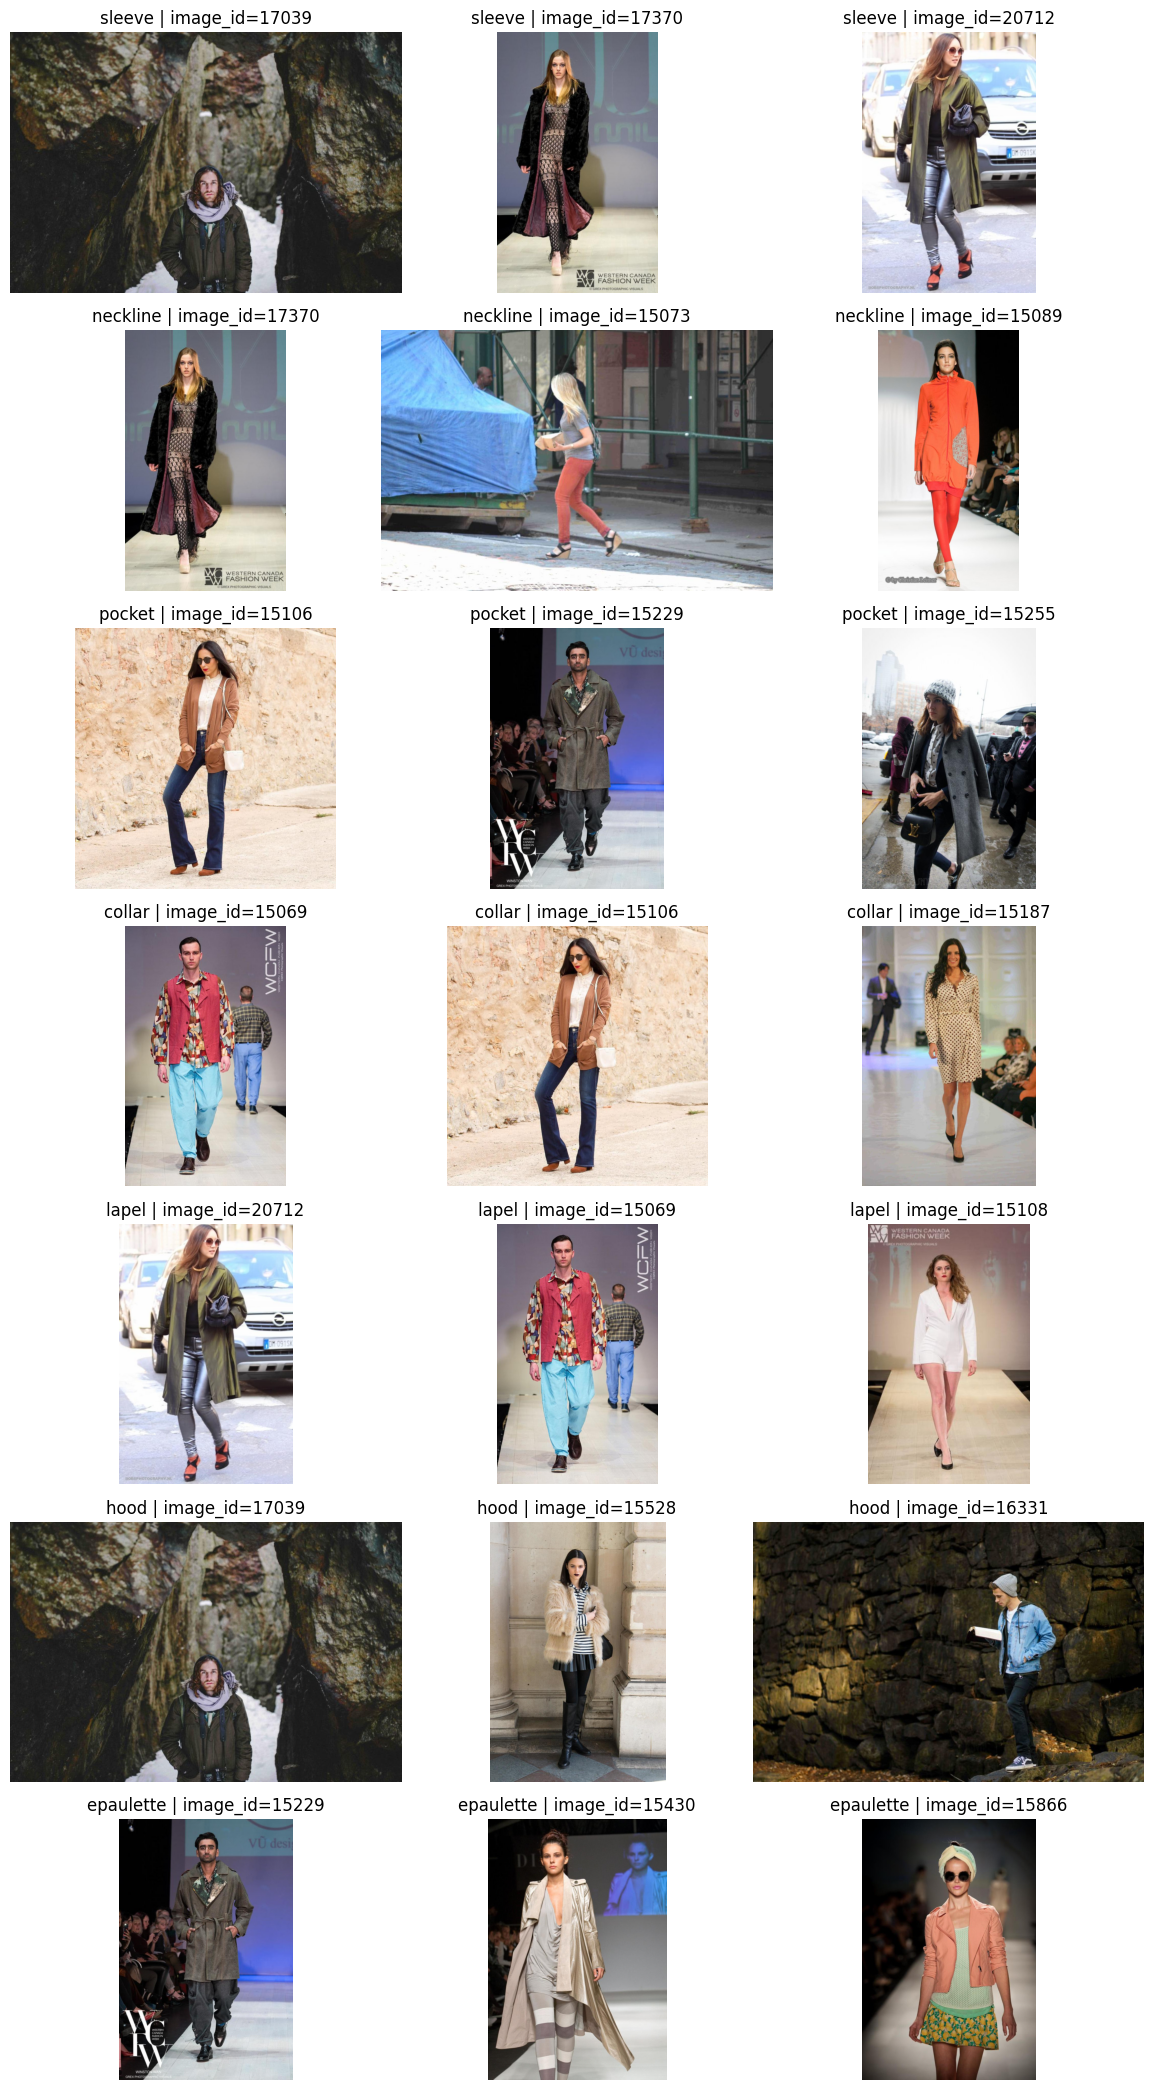

Quantidade de exemplos encontrados por categoria:
- sleeve: 3
- neckline: 3
- pocket: 3
- collar: 3
- lapel: 3
- hood: 3
- epaulette: 3


In [75]:
import zipfile
from io import BytesIO
from PIL import Image

import matplotlib.pyplot as plt

# Categorias solicitadas
target_categories = ['sleeve', 'neckline', 'pocket', 'collar', 'lapel', 'hood', 'epaulette']
max_por_categoria = 3  # quantidade de exemplos por categoria

# Mapeamentos já disponíveis no notebook
image_by_id = {img['id']: img for img in images}
cat_id_by_name = {name: cid for cid, name in category_name_by_id.items()}

# Descobrir zip (ou use DATASET_ZIP_PATH = Path("...") em uma célula antes)
zip_path = globals().get('DATASET_ZIP_PATH')
if zip_path is None:
    candidatos = list(Path('original_dataset').glob('*.zip')) + list(Path('.').glob('*.zip'))
    if not candidatos:
        raise FileNotFoundError('Nenhum arquivo .zip encontrado. Defina DATASET_ZIP_PATH com o caminho do zip de imagens.')
    zip_path = candidatos[0]

zip_path = Path(zip_path)
print(f'Usando ZIP: {zip_path}')

# Coletar image_ids por categoria
img_ids_por_categoria = {}
for cat_name in target_categories:
    cid = cat_id_by_name.get(cat_name)
    if cid is None:
        img_ids_por_categoria[cat_name] = []
        continue

    ids = []
    for ann in annotations:
        if ann.get('category_id') == cid:
            img_id = ann.get('image_id')
            if img_id in image_by_id:
                ids.append(img_id)

    # remover duplicatas mantendo ordem
    ids_unicos = list(dict.fromkeys(ids))
    img_ids_por_categoria[cat_name] = ids_unicos[:max_por_categoria]

# Abrir ZIP e indexar arquivos por basename
with zipfile.ZipFile(zip_path, 'r') as zf:
    membros = zf.namelist()
    membros_por_basename = {}
    for m in membros:
        base = Path(m).name
        membros_por_basename.setdefault(base, []).append(m)

    def carregar_imagem_do_zip(file_name):
        # tenta match exato, depois por basename
        membro = file_name if file_name in membros else None
        if membro is None:
            possiveis = membros_por_basename.get(Path(file_name).name, [])
            membro = possiveis[0] if possiveis else None
        if membro is None:
            return None

        data_img = zf.read(membro)
        return Image.open(BytesIO(data_img)).convert('RGB')

    # Plot
    n_rows = len(target_categories)
    n_cols = max_por_categoria
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

    if n_rows == 1:
        axes = [axes]

    for i, cat_name in enumerate(target_categories):
        ids = img_ids_por_categoria.get(cat_name, [])
        for j in range(n_cols):
            ax = axes[i][j] if n_cols > 1 else axes[i]
            ax.axis('off')

            if j >= len(ids):
                ax.set_title(f'{cat_name}\nsem exemplo')
                continue

            img_id = ids[j]
            file_name = image_by_id[img_id]['file_name']
            img = carregar_imagem_do_zip(file_name)

            if img is None:
                ax.set_title(f'{cat_name}\n{file_name}\n(não encontrado no zip)')
                continue

            ax.imshow(img)
            ax.set_title(f'{cat_name} | image_id={img_id}')

    plt.tight_layout()
    plt.show()

print('Quantidade de exemplos encontrados por categoria:')
for cat_name in target_categories:
    print(f'- {cat_name}: {len(img_ids_por_categoria.get(cat_name, []))}')

In [ ]:
category_ids_por_frequencia = [cid for cid, _ in category_counter.most_common()]

# print(category_ids_por_frequencia)
ranking_ids_annotations_frequencia = [
    {
        # 'id': cid,
        'annotation': category_name_by_id.get(cid),
        'frequencia': freq
    }
    for cid, freq in category_counter.most_common()
]

for row in ranking_ids_annotations_frequencia:
    print(f"{row['annotation']} | frequency: {row['frequencia']}")

shoe | frequency: 1566
sleeve | frequency: 1442
neckline | frequency: 929
pocket | frequency: 541
dress | frequency: 508
top, t-shirt, sweatshirt | frequency: 477
pants | frequency: 314
collar | frequency: 218
bag, wallet | frequency: 214
zipper | frequency: 194
jacket | frequency: 183
belt | frequency: 164
skirt | frequency: 162
rivet | frequency: 143
lapel | frequency: 135
glasses | frequency: 130
tights, stockings | frequency: 122
headband, head covering, hair accessory | frequency: 109
bead | frequency: 107
shorts | frequency: 106
coat | frequency: 104
shirt, blouse | frequency: 102
sock | frequency: 87
watch | frequency: 84
ruffle | frequency: 76
hat | frequency: 74
buckle | frequency: 67
applique | frequency: 61
scarf | frequency: 48
tassel | frequency: 39
flower | frequency: 37
hood | frequency: 32
glove | frequency: 31
fringe | frequency: 30
vest | frequency: 22
jumpsuit | frequency: 21
sweater | frequency: 21
epaulette | frequency: 14
leg warmer | frequency: 14
sequin | freque

In [76]:
# Remove categorias específicas do dataset (e suas anotações associadas)
categorias_remover = ['sleeve', 'neckline', 'pocket', 'collar', 'lapel', 'hood', 'epaulette']

# Usa o dataset limpo sem imagens, se existir; caso contrário, usa o dataset original
base_dataset = data_no_images if 'data_no_images' in globals() else data

cats_base = base_dataset.get('categories', [])
anns_base = base_dataset.get('annotations', [])

cat_id_by_name_base = {c.get('name'): c.get('id') for c in cats_base}
ids_remover = {cat_id_by_name_base[n] for n in categorias_remover if n in cat_id_by_name_base}

categorias_filtradas = [c for c in cats_base if c.get('id') not in ids_remover]
anotacoes_filtradas = [a for a in anns_base if a.get('category_id') not in ids_remover]

data_sem_categorias = dict(base_dataset)
data_sem_categorias['categories'] = categorias_filtradas
data_sem_categorias['annotations'] = anotacoes_filtradas

# Salva em final_datasets
final_dir.mkdir(exist_ok=True)
no_selected_cats_path = final_dir / 'instances_attributes_val2020_clean_no_selected_categories.json'
no_selected_cats_path.write_text(
    json.dumps(data_sem_categorias, ensure_ascii=False),
    encoding='utf-8'
)

print('Categorias removidas:', categorias_remover)
print('IDs removidos:', sorted(ids_remover))
print(f'Categorias: {len(cats_base)} -> {len(categorias_filtradas)}')
print(f'Anotações: {len(anns_base)} -> {len(anotacoes_filtradas)}')
print(f'Arquivo salvo em: {no_selected_cats_path}')

Categorias removidas: ['sleeve', 'neckline', 'pocket', 'collar', 'lapel', 'hood', 'epaulette']
IDs removidos: [27, 28, 29, 30, 31, 32, 33]
Categorias: 46 -> 39
Anotações: 8781 -> 5470
Arquivo salvo em: final_datasets\instances_attributes_val2020_clean_no_selected_categories.json


### attribute_ids cleaning

In [77]:
ranking_attribute_ids_frequencia = sorted(
    [
        {
            'attribute_id': attr.get('id'),
            'attribute': attr.get('name'),
            'frequencia': attribute_counter.get(attr.get('id'), 0),
        }
        for attr in attributes
    ],
    key=lambda x: x['frequencia'],
    reverse=True
)

for row in ranking_attribute_ids_frequencia:
    print(f"{row['attribute_id']} | {row['attribute']} | frequency: {row['frequencia']}")

115 | symmetrical | frequency: 1895
295 | no non-textile material | frequency: 1778
317 | plain (pattern) | frequency: 1548
316 | no special manufacturing technique | frequency: 1135
204 | set-in sleeve | frequency: 846
160 | wrist-length | frequency: 814
136 | regular (fit) | frequency: 630
142 | normal waist | frequency: 600
145 | no waistline | frequency: 524
146 | above-the-hip (length) | frequency: 506
229 | zip-up | frequency: 493
135 | tight (fit) | frequency: 437
149 | mini (length) | frequency: 336
157 | short (length) | frequency: 305
141 | high waist | frequency: 304
230 | fly (opening) | frequency: 297
154 | maxi (length) | frequency: 256
128 | straight | frequency: 236
225 | single breasted | frequency: 231
137 | loose (fit) | frequency: 218
182 | round (neck) | frequency: 195
305 | gathering | frequency: 154
159 | three quarter (length) | frequency: 146
147 | hip (length) | frequency: 144
0 | classic (t-shirt) | frequency: 141
127 | pencil | frequency: 133
298 | washed | 

In [78]:
from collections import defaultdict

# Supercategories das categorias
supercategory_counter = Counter()
supercategory_by_name = {}

for c in categories:
    supercat = c.get('supercategory', 'N/A')
    cat_name = c.get('name')
    cid = c.get('id')
    supercategory_by_name[cat_name] = supercat
    # Soma as anotações da categoria filha na supercategoria
    supercategory_counter[supercat] += category_counter.get(cid, 0)

# Lista única de supercategorias
supercats_unicas = sorted(set(c.get('supercategory', 'N/A') for c in categories))
print(f'Total de supercategorias únicas: {len(supercats_unicas)}')
print('\nSupercategorias:')
for s in supercats_unicas:
    print(f'  - {s}')

# Balanceamento por supercategoria
total_anns = sum(supercategory_counter.values())
print(f'\n{"Supercategoria":<40} {"Anotações":>12} {"% do total":>12}')
print('-' * 66)
for supercat, cnt in supercategory_counter.most_common():
    pct = cnt / total_anns * 100 if total_anns > 0 else 0
    print(f'{supercat:<40} {cnt:>12} {pct:>11.2f}%')

# Categorias por supercategoria
print('\nCategorias agrupadas por supercategoria:')
cats_por_super = defaultdict(list)
for c in categories:
    cats_por_super[c.get('supercategory', 'N/A')].append(c.get('name'))

for supercat in sorted(cats_por_super):
    print(f'\n  [{supercat}]')
    for cat_name in sorted(cats_por_super[supercat]):
        cnt = category_counter.get(
            next((c['id'] for c in categories if c['name'] == cat_name), None), 0
        )
        print(f'    - {cat_name}: {cnt} anotações')

# Gini da distribuição de supercategorias
supercat_values = list(supercategory_counter.values())
supercat_gini = gini(supercat_values)
supercat_entropy = shannon_entropy(Counter({i: v for i, v in enumerate(supercat_values)}))

print(f'\nGini das supercategorias : {supercat_gini:.4f}')
print(f'Entropia (Shannon) bits  : {supercat_entropy:.4f}')

Total de supercategorias únicas: 12

Supercategorias:
  - arms and hands
  - closures
  - decorations
  - garment parts
  - head
  - legs and feet
  - lowerbody
  - neck
  - others
  - upperbody
  - waist
  - wholebody

Supercategoria                              Anotações   % do total
------------------------------------------------------------------
garment parts                                    3311       37.71%
legs and feet                                    1789       20.37%
upperbody                                         817        9.30%
wholebody                                         638        7.27%
lowerbody                                         582        6.63%
decorations                                       521        5.93%
head                                              313        3.56%
others                                            267        3.04%
closures                                          261        2.97%
waist                                      